In [56]:
import yfinance as yf
import os
import pandas as pd

In [57]:
btc_ticker = yf.Ticker("BTC-USD")

In [58]:
if os.path.exists("btc.csv"):
    btc = pd.read_csv("btc.csv", index_col=0)
else:
    btc = btc_ticker.history(period="max")
    btc.to_csv("btc.csv")

In [59]:
btc

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0
...,...,...,...,...,...,...,...
2023-09-30 00:00:00+00:00,26911.689453,27091.794922,26888.968750,26967.916016,5331172801,0.0,0.0
2023-10-01 00:00:00+00:00,26967.396484,28047.238281,26965.093750,27983.750000,9503917434,0.0,0.0
2023-10-02 00:00:00+00:00,27976.798828,28494.458984,27347.787109,27530.785156,19793041322,0.0,0.0


In [60]:
btc.index = pd.to_datetime(btc.index)

In [61]:
del btc["Dividends"]
del btc["Stock Splits"]

In [62]:
btc.columns = [c.lower() for c in btc.columns]

<AxesSubplot:xlabel='Date'>

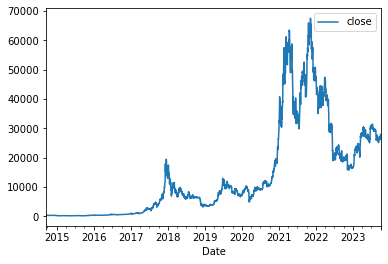

In [63]:
btc.plot.line(y="close", use_index=True)

In [64]:
wiki = pd.read_csv("wikipedia_edits.csv", index_col=0, parse_dates=True)

In [65]:
wiki

,edit_count,sentiment,neg_sentiment
2009-04-06,0.133333,-0.018351,0.025000
2009-04-07,0.000000,0.000000,0.000000
2009-04-08,0.000000,0.000000,0.000000
2009-04-09,0.000000,0.000000,0.000000
2009-04-10,0.000000,0.000000,0.000000
...,...,...,...
2023-09-30,0.766667,-0.121405,0.193056
2023-10-01,0.766667,-0.121405,0.193056
2023-10-02,0.766667,-0.121405,0.193056
2023-10-03,0.766667,-0.121405,0.193056


In [66]:
missing_values = df.isna().sum()

In [67]:
df.fillna(df.mean(), inplace=True)

C:\Users\SURUJ_KALITA\AppData\Local\Temp\ipykernel_21652\820435583.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.fillna(df.mean(), inplace=True)
C:\Users\SURUJ_KALITA\AppData\Local\Temp\ipykernel_21652\820435583.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(df.mean(), inplace=True)


In [68]:
df["tomorrow"] = df["Close"].shift(-1)

C:\Users\SURUJ_KALITA\AppData\Local\Temp\ipykernel_21652\2485269633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tomorrow"] = df["Close"].shift(-1)


In [69]:
df["target"] = (df["tomorrow"] > df["Close"]).astype(int)


C:\Users\SURUJ_KALITA\AppData\Local\Temp\ipykernel_21652\3673621234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target"] = (df["tomorrow"] > df["Close"]).astype(int)


In [70]:
df["target"].value_counts()

1    1747
0    1558
Name: target, dtype: int64

In [71]:
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,edit_count,sentiment,neg_sentiment,tomorrow,target
0,2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,2.105680e+07,0.0,0.0,3.25028,-0.193354,0.341477,424.440002,0
1,2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,3.448320e+07,0.0,0.0,3.25028,-0.193354,0.341477,394.795990,0
2,2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,3.791970e+07,0.0,0.0,3.25028,-0.193354,0.341477,408.903992,1
3,2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,3.686360e+07,0.0,0.0,3.25028,-0.193354,0.341477,398.821014,0
4,2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,2.658010e+07,0.0,0.0,3.25028,-0.193354,0.341477,402.152008,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3300,2023-09-30 00:00:00+00:00,26911.689453,27091.794922,26888.968750,26967.916016,5.331173e+09,0.0,0.0,3.25028,-0.193354,0.341477,27983.750000,1
3301,2023-10-01 00:00:00+00:00,26967.396484,28047.238281,26965.093750,27983.750000,9.503917e+09,0.0,0.0,3.25028,-0.193354,0.341477,27530.785156,0
3302,2023-10-02 00:00:00+00:00,27976.798828,28494.458984,27347.787109,27530.785156,1.979304e+10,0.0,0.0,3.25028,-0.193354,0.341477,27429.978516,0
3303,2023-10-03 00:00:00+00:00,27508.251953,27667.191406,27216.001953,27429.978516,1.140781e+10,0.0,0.0,3.25028,-0.193354,0.341477,27529.884766,1


In [72]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)

train = df.iloc[:-200]
test = df.iloc[-200:]

predictors = ["Volume", "Open", "High", "Low", "Close", "Volume", "Dividends",'edit_count','sentiment','neg_sentiment','tomorrow','target']
model.fit(train[predictors], train["target"])

RandomForestClassifier(min_samples_split=50, random_state=1)

In [73]:
df = df.dropna()

In [74]:
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,edit_count,sentiment,neg_sentiment,tomorrow,target
0,2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,2.105680e+07,0.0,0.0,3.25028,-0.193354,0.341477,424.440002,0
1,2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,3.448320e+07,0.0,0.0,3.25028,-0.193354,0.341477,394.795990,0
2,2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,3.791970e+07,0.0,0.0,3.25028,-0.193354,0.341477,408.903992,1
3,2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,3.686360e+07,0.0,0.0,3.25028,-0.193354,0.341477,398.821014,0
4,2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,2.658010e+07,0.0,0.0,3.25028,-0.193354,0.341477,402.152008,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3299,2023-09-29 00:00:00+00:00,27024.841797,27225.937500,26721.763672,26911.720703,1.039644e+10,0.0,0.0,3.25028,-0.193354,0.341477,26967.916016,1
3300,2023-09-30 00:00:00+00:00,26911.689453,27091.794922,26888.968750,26967.916016,5.331173e+09,0.0,0.0,3.25028,-0.193354,0.341477,27983.750000,1
3301,2023-10-01 00:00:00+00:00,26967.396484,28047.238281,26965.093750,27983.750000,9.503917e+09,0.0,0.0,3.25028,-0.193354,0.341477,27530.785156,0
3302,2023-10-02 00:00:00+00:00,27976.798828,28494.458984,27347.787109,27530.785156,1.979304e+10,0.0,0.0,3.25028,-0.193354,0.341477,27429.978516,0


In [75]:
##be careful dealing with timeseries data so while choosing for machine tuning 
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)

train = df.iloc[:-200]
test = df.iloc[-200:]

predictors = ["Open", "High", "Low", "Close", "Volume", "edit_count", "sentiment", "neg_sentiment"]
model.fit(train[predictors], train["target"])

RandomForestClassifier(min_samples_split=50, random_state=1)

In [12]:
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Unnamed: 0,edit_count,sentiment,neg_sentiment
0,2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200.0,0.0,0.0,NaN,NaN,NaN,NaN
2,2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700.0,0.0,0.0,NaN,NaN,NaN,NaN
3,2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600.0,0.0,0.0,NaN,NaN,NaN,NaN
4,2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100.0,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-09-30,0.766667,-0.121405,0.193056
8596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-10-01,0.766667,-0.121405,0.193056
8597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-10-02,0.766667,-0.121405,0.193056
8598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-10-03,0.766667,-0.121405,0.193056


In [13]:
df["tomorrow"] = df["Close"].shift(-1)

In [14]:
df["target"] = (df["tomorrow"] > df["Close"]).astype(int)

In [15]:
df["target"].value_counts()

0    6853
1    1747
Name: target, dtype: int64

In [78]:
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,edit_count,sentiment,neg_sentiment,tomorrow,target
0,2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,2.105680e+07,0.0,0.0,3.25028,-0.193354,0.341477,424.440002,0
1,2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,3.448320e+07,0.0,0.0,3.25028,-0.193354,0.341477,394.795990,0
2,2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,3.791970e+07,0.0,0.0,3.25028,-0.193354,0.341477,408.903992,1
3,2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,3.686360e+07,0.0,0.0,3.25028,-0.193354,0.341477,398.821014,0
4,2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,2.658010e+07,0.0,0.0,3.25028,-0.193354,0.341477,402.152008,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3299,2023-09-29 00:00:00+00:00,27024.841797,27225.937500,26721.763672,26911.720703,1.039644e+10,0.0,0.0,3.25028,-0.193354,0.341477,26967.916016,1
3300,2023-09-30 00:00:00+00:00,26911.689453,27091.794922,26888.968750,26967.916016,5.331173e+09,0.0,0.0,3.25028,-0.193354,0.341477,27983.750000,1
3301,2023-10-01 00:00:00+00:00,26967.396484,28047.238281,26965.093750,27983.750000,9.503917e+09,0.0,0.0,3.25028,-0.193354,0.341477,27530.785156,0
3302,2023-10-02 00:00:00+00:00,27976.798828,28494.458984,27347.787109,27530.785156,1.979304e+10,0.0,0.0,3.25028,-0.193354,0.341477,27429.978516,0


In [79]:
##be careful dealing with timeseries data so while choosing for machine tuning 
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)

train = df.iloc[:-200]
test = df.iloc[-200:]

predictors = ["Open", "High", "Low", "Close", "Volume", "edit_count", "sentiment", "neg_sentiment"]
model.fit(train[predictors], train["target"])

RandomForestClassifier(min_samples_split=50, random_state=1)

In [80]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision_score(test["target"], preds)

0.43333333333333335

In [81]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="predictions")
    combined = pd.concat([test["target"], preds], axis=1)
    return combined

In [82]:
def backtest(data, model, predictors, start=1095, step=150):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    
    return pd.concat(all_predictions)

In [84]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=1, learning_rate=.1, n_estimators=200)
predictions = backtest(df, model, predictors)

In [85]:
predictions["predictions"].value_counts()

1    1425
0     784
Name: predictions, dtype: int64

In [86]:
precision_score(predictions["target"], predictions["predictions"])

0.5087719298245614

In [88]:
def compute_rolling(df):
    horizons = [2,7,60,365]
    new_predictors = ["Close", "sentiment", "neg_sentiment"]

    for horizon in horizons:
        rolling_averages = df.rolling(horizon, min_periods=1).mean()

        ratio_column = f"close_ratio_{horizon}"
        df[ratio_column] = df["Close"] / rolling_averages["Close"]
        
        edit_column = f"edit_{horizon}"
        df[edit_column] = rolling_averages["edit_count"]

        rolling = df.rolling(horizon, closed='left', min_periods=1).mean()
        trend_column = f"trend_{horizon}"
        df[trend_column] = rolling["target"]

        new_predictors+= [ratio_column, trend_column, edit_column]
    return df, new_predictors

In [89]:
df, new_predictors = compute_rolling(df.copy())

C:\Users\SURUJ_KALITA\AppData\Local\Temp\ipykernel_21652\991677790.py:6: FutureWarning: Dropping of nuisance columns in rolling operations is deprecated; in a future version this will raise TypeError. Select only valid columns before calling the operation. Dropped columns were Index(['Date'], dtype='object')
  rolling_averages = df.rolling(horizon, min_periods=1).mean()
C:\Users\SURUJ_KALITA\AppData\Local\Temp\ipykernel_21652\991677790.py:14: FutureWarning: Dropping of nuisance columns in rolling operations is deprecated; in a future version this will raise TypeError. Select only valid columns before calling the operation. Dropped columns were Index(['Date'], dtype='object')
  rolling = df.rolling(horizon, closed='left', min_periods=1).mean()
C:\Users\SURUJ_KALITA\AppData\Local\Temp\ipykernel_21652\991677790.py:6: FutureWarning: Dropping of nuisance columns in rolling operations is deprecated; in a future version this will raise TypeError. Select only valid columns before calling the o

In [90]:
predictions = backtest(df, model, new_predictors)

In [91]:
precision_score(predictions["target"], predictions["predictions"])

0.5075421472937001

In [92]:
predictions

,target,predictions
1095,0,1
1096,1,0
1097,0,0
1098,0,1
1099,0,1
...,...,...
3299,1,0
3300,1,0
3301,0,1
3302,0,1


In [93]:
import pickle
##improvise using other trends for finances
##other datasequences 